## 0. Notebook Objective & Scope
Establish transparent baseline classification performance across the four Track A cardiovascular prediction tasks (Cath, LAD, LCX, RCA) using Logistic Regression, Linear SVM, RBF SVM, and Random Forest. Experiments evaluate both Preprocessing Configuration A (Ordinal VHD, 56 features) and Configuration B (One-Hot VHD, 59 features) strictly on the 242-row development cohort via target-specific Repeated Stratified 5-Fold CV (25 evaluations per configuration, totaling 800 fits). The 61-row holdout test set remains sealed until Notebook 6.

## 1. Environment & Reproducibility

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)

## 2. Load Frozen Modeling Contract
Load raw data and the locked configuration schema from Notebook 2.

In [2]:
with open('preprocessing_config.json', 'r') as f:
    config = json.load(f)

DATA_PATH = Path('extention of Z-Alizadeh sani dataset.xlsx')
df_raw = pd.read_excel(DATA_PATH)
df = df_raw.copy()

# Deterministic cleaning verified in Notebook 2
df['Sex'] = df['Sex'].replace({'Fmale': 'Female'})
df = df.drop(columns=config['dropped_features'])

TARGET_COLUMNS = config['target_columns']
TARGET_MAPPINGS = config['target_mappings']

y_df = pd.DataFrame(index=df.index)
for target in TARGET_COLUMNS:
    y_df[target] = df[target].map(TARGET_MAPPINGS[target]).astype(int)

X_raw = df.drop(columns=TARGET_COLUMNS).copy()

train_indices = config['train_indices']
holdout_indices = config['holdout_indices']

X_dev = X_raw.iloc[train_indices].copy().reset_index(drop=True)
y_dev = y_df.iloc[train_indices].copy().reset_index(drop=True)

X_holdout = X_raw.iloc[holdout_indices].copy().reset_index(drop=True)
y_holdout = y_df.iloc[holdout_indices].copy().reset_index(drop=True)

print(f"Development Set: {len(X_dev)} records | Holdout Set: {len(X_holdout)} records (Sealed)")

Development Set: 242 records | Holdout Set: 61 records (Sealed)


## 3. Dataset & Target Isolation Verification
Verify that the four target columns are strictly segregated from the candidate feature matrix.

In [3]:
assert len(X_dev) == 242, f"Expected 242 dev records, got {len(X_dev)}"
assert len(X_holdout) == 61, f"Expected 61 holdout records, got {len(X_holdout)}"
assert len(set(train_indices) & set(holdout_indices)) == 0, "Overlap in train/holdout indices"
assert not any(t in X_dev.columns for t in TARGET_COLUMNS), "Target leakage in X_dev"
assert not any(t in X_holdout.columns for t in TARGET_COLUMNS), "Target leakage in X_holdout"

print("Integrity verification passed: Zero target leakage and clean dataset partitions.")

Integrity verification passed: Zero target leakage and clean dataset partitions.


## 4. Define the Four Prediction Tasks

In [4]:
TARGETS = {
    'Cath': {'label': 'Overall CAD', 'pos_class': 'CAD', 'dev_pos_pct': y_dev['Cath'].mean() * 100},
    'LAD':  {'label': 'LAD Stenosis', 'pos_class': 'Stenotic', 'dev_pos_pct': y_dev['LAD'].mean() * 100},
    'LCX':  {'label': 'LCX Stenosis', 'pos_class': 'Stenotic', 'dev_pos_pct': y_dev['LCX'].mean() * 100},
    'RCA':  {'label': 'RCA Stenosis', 'pos_class': 'Stenotic', 'dev_pos_pct': y_dev['RCA'].mean() * 100}
}
display(pd.DataFrame(TARGETS).T)

,label,pos_class,dev_pos_pct
Cath,Overall CAD,CAD,71.487603
LAD,LAD Stenosis,Stenotic,59.090909
LCX,LCX Stenosis,Stenotic,38.429752
RCA,RCA Stenosis,Stenotic,38.842975


## 5. Define Baseline Model Families
Instantiate Logistic Regression, Linear SVM, RBF SVM, and Random Forest using fixed random seeds.

In [5]:
BASE_MODELS = {
    'LogisticRegression': LogisticRegression(
        max_iter=5000,
        random_state=RANDOM_STATE
    ),
    'LinearSVM': SVC(
        kernel='linear',
        probability=True,
        random_state=RANDOM_STATE
    ),
    'RBF_SVM': SVC(
        kernel='rbf',
        probability=True,
        random_state=RANDOM_STATE
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=None
    )
}
for name, m in BASE_MODELS.items():
    print(f"Model initialized: {name:20s} -> {m.__class__.__name__}")

Model initialized: LogisticRegression   -> LogisticRegression
Model initialized: LinearSVM            -> SVC
Model initialized: RBF_SVM              -> SVC
Model initialized: RandomForest         -> RandomForestClassifier


## 6. Build Leakage-Safe Preprocessing Pipelines
Construct full ColumnTransformers for Preprocessing Configuration A (Ordinal VHD, 56 features) and Configuration B (One-Hot VHD, 59 features).

In [6]:
fg = config['feature_groups']

ALL_NUMERIC_FEATURES = fg['all_numeric_features']
BINARY_STR_FEATURES = fg['binary_str_features']
BINARY_NUM_FEATURES = fg['binary_num_features']
SEX_FEATURE = fg['sex_feature']
NOMINAL_FEATURES = fg['nominal_features']
ORDINAL_CAT_FEATURES = fg['ordinal_cat_features']

numeric_pipeline = Pipeline([('scaler', StandardScaler())])

binary_str_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(
        categories=[['N', 'Y']] * len(BINARY_STR_FEATURES),
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

sex_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(
        categories=[['Female', 'Male']],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

bbb_pipeline = Pipeline([
    ('ohe', OneHotEncoder(
        categories=[['N', 'LBBB', 'RBBB']],
        handle_unknown='ignore',
        sparse_output=False
    ))
])

vhd_ordinal_pipeline = Pipeline([
    ('ordinal', OrdinalEncoder(
        categories=[['N', 'mild', 'Moderate', 'Severe']],
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

vhd_onehot_pipeline = Pipeline([
    ('ohe', OneHotEncoder(
        categories=[['N', 'mild', 'Moderate', 'Severe']],
        handle_unknown='ignore',
        sparse_output=False
    ))
])

def build_preprocessor(vhd_mode='ordinal'):
    vhd_pipe = vhd_ordinal_pipeline if vhd_mode == 'ordinal' else vhd_onehot_pipeline
    transformers = [
        ('num', numeric_pipeline, ALL_NUMERIC_FEATURES),
        ('bin_str', binary_str_pipeline, BINARY_STR_FEATURES),
        ('sex', sex_pipeline, SEX_FEATURE),
        ('bbb', bbb_pipeline, NOMINAL_FEATURES),
        ('vhd', vhd_pipe, ORDINAL_CAT_FEATURES),
        ('bin_num', 'passthrough', BINARY_NUM_FEATURES)
    ]
    return ColumnTransformer(transformers=transformers, remainder='drop')

PREPROCESSORS = {
    'Config_A_Ordinal': build_preprocessor(vhd_mode='ordinal'),
    'Config_B_OneHot': build_preprocessor(vhd_mode='onehot')
}

for name, prep in PREPROCESSORS.items():
    prep.fit(X_dev)
    print(f"{name:20s}: Transformed output features = {len(prep.get_feature_names_out())}")

Config_A_Ordinal    : Transformed output features = 56
Config_B_OneHot     : Transformed output features = 59


## 7. Target-Specific Cross-Validation Splitters
Configure independent RepeatedStratifiedKFold splitters for each target (5 splits x 5 repeats = 25 evaluations).

In [7]:
TARGET_CV_SPLITTERS = {
    target: RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
    for target in TARGET_COLUMNS
}
print("Initialized 4 target-specific RepeatedStratifiedKFold splitters (25 evaluations each).")

Initialized 4 target-specific RepeatedStratifiedKFold splitters (25 evaluations each).


## 8. Cross-Validation Evaluation Engine
Evaluates pipelines strictly fitting the ColumnTransformer and estimator inside each training fold to eliminate leakage.

In [8]:
def evaluate_pipeline(pipeline, X, y, cv_splitter, target_name, model_name, prep_name):
    records = []
    rep1_oof_predictions = np.zeros(len(X))
    rep1_oof_probabilities = np.zeros(len(X))
    fold_counter = 0

    for fold_idx, (train_i, val_i) in enumerate(cv_splitter.split(X, y)):
        fold_counter += 1
        repeat_num = (fold_idx // 5) + 1
        fold_num = (fold_idx % 5) + 1

        X_tr, y_tr = X.iloc[train_i], y.iloc[train_i]
        X_va, y_val = X.iloc[val_i], y.iloc[val_i]

        # Fit cloned pipeline strictly on fold training data
        fold_pipe = clone(pipeline)
        fold_pipe.fit(X_tr, y_tr)

        # Predict on unseen validation fold
        y_prob = fold_pipe.predict_proba(X_va)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        acc = accuracy_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        auc = roc_auc_score(y_val, y_prob)
        pr_auc = average_precision_score(y_val, y_prob)

        records.append({
            'target': target_name,
            'preprocessing': prep_name,
            'model': model_name,
            'evaluation_idx': fold_counter,
            'repeat': repeat_num,
            'fold': fold_num,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'roc_auc': auc,
            'pr_auc': pr_auc
        })
        
        # Save first repetition (folds 1-5, indices 0-4) for diagnostic confusion matrices
        if fold_idx < 5:
            rep1_oof_predictions[val_i] = y_pred
            rep1_oof_probabilities[val_i] = y_prob

    return pd.DataFrame(records), rep1_oof_predictions, rep1_oof_probabilities

## 9. Execute Baseline Experiment Matrix
Run 32 configurations (4 targets x 2 preprocessing configs x 4 model families) across 25 folds = 800 fitted pipelines.

In [9]:
all_fold_results = []
rep1_oof_dict = {}

total_configs = len(TARGET_COLUMNS) * len(PREPROCESSORS) * len(BASE_MODELS)
config_idx = 0

print(f"Beginning 32 experiment configurations across 25 folds (800 model fits)...")

for target in TARGET_COLUMNS:
    y_target = y_dev[target]
    cv_splitter = TARGET_CV_SPLITTERS[target]

    for prep_name, prep_obj in PREPROCESSORS.items():
        for model_name, model_obj in BASE_MODELS.items():
            config_idx += 1
            pipe = Pipeline([
                ('preprocessor', prep_obj),
                ('model', model_obj)
            ])

            res_df, oof_pred, oof_prob = evaluate_pipeline(
                pipe, X_dev, y_target, cv_splitter,
                target_name=target, model_name=model_name, prep_name=prep_name
            )
            all_fold_results.append(res_df)
            oof_key = f"{target}__{prep_name}__{model_name}"
            rep1_oof_dict[oof_key] = {'pred': oof_pred, 'prob': oof_prob}

baseline_results_df = pd.concat(all_fold_results, ignore_index=True)
print(f"Experiment matrix execution complete! Total fold evaluations logged: {len(baseline_results_df)}")
assert len(baseline_results_df) == 800, f"Expected 800 fold records, got {len(baseline_results_df)}"

Beginning 32 experiment configurations across 25 folds (800 model fits)...


Experiment matrix execution complete! Total fold evaluations logged: 800


## 10. Aggregate Performance Summary
Mean and standard deviation for ROC-AUC, F1, Recall, Precision, and Accuracy across all 25 folds.

In [10]:
summary_df = baseline_results_df.groupby(['target', 'preprocessing', 'model']).agg(
    roc_auc_mean=('roc_auc', 'mean'),
    roc_auc_std=('roc_auc', 'std'),
    f1_mean=('f1', 'mean'),
    f1_std=('f1', 'std'),
    recall_mean=('recall', 'mean'),
    recall_std=('recall', 'std'),
    precision_mean=('precision', 'mean'),
    precision_std=('precision', 'std'),
    accuracy_mean=('accuracy', 'mean'),
    accuracy_std=('accuracy', 'std'),
    pr_auc_mean=('pr_auc', 'mean')
).reset_index()

summary_formatted = summary_df.copy()
for metric in ['roc_auc', 'f1', 'recall', 'precision', 'accuracy']:
    summary_formatted[metric] = summary_formatted.apply(
        lambda r: f"{r[metric+'_mean']:.3f} +/- {r[metric+'_std']:.3f}", axis=1
    )

display_cols = ['target', 'preprocessing', 'model', 'roc_auc', 'f1', 'recall', 'precision', 'accuracy', 'pr_auc_mean']
display(summary_formatted[display_cols].sort_values(['target', 'roc_auc'], ascending=[True, False]))

,target,preprocessing,model,roc_auc,f1,recall,precision,accuracy,pr_auc_mean
7,Cath,Config_B_OneHot,RandomForest,0.932 +/- 0.039,0.912 +/- 0.026,0.947 +/- 0.039,0.881 +/- 0.032,0.869 +/- 0.038,0.971108
3,Cath,Config_A_Ordinal,RandomForest,0.931 +/- 0.040,0.911 +/- 0.027,0.943 +/- 0.047,0.883 +/- 0.030,0.869 +/- 0.038,0.970211
1,Cath,Config_A_Ordinal,LogisticRegression,0.923 +/- 0.029,0.896 +/- 0.028,0.903 +/- 0.051,0.891 +/- 0.028,0.851 +/- 0.038,0.969624
5,Cath,Config_B_OneHot,LogisticRegression,0.918 +/- 0.032,0.896 +/- 0.032,0.896 +/- 0.055,0.897 +/- 0.026,0.852 +/- 0.042,0.966888
0,Cath,Config_A_Ordinal,LinearSVM,0.909 +/- 0.026,0.884 +/- 0.030,0.903 +/- 0.051,0.870 +/- 0.049,0.831 +/- 0.045,0.964076
2,Cath,Config_A_Ordinal,RBF_SVM,0.902 +/- 0.042,0.892 +/- 0.030,0.912 +/- 0.054,0.875 +/- 0.028,0.844 +/- 0.041,0.958773
4,Cath,Config_B_OneHot,LinearSVM,0.899 +/- 0.032,0.881 +/- 0.028,0.891 +/- 0.053,0.875 +/- 0.044,0.829 +/- 0.040,0.958727
6,Cath,Config_B_OneHot,RBF_SVM,0.898 +/- 0.042,0.889 +/- 0.032,0.910 +/- 0.058,0.872 +/- 0.028,0.840 +/- 0.043,0.957512
11,LAD,Config_A_Ordinal,RandomForest,0.854 +/- 0.056,0.845 +/- 0.046,0.899 +/- 0.047,0.798 +/- 0.061,0.803 +/- 0.063,0.881227
15,LAD,Config_B_OneHot,RandomForest,0.852 +/- 0.050,0.842 +/- 0.039,0.898 +/- 0.046,0.795 +/- 0.053,0.801 +/- 0.052,0.878227


## 11. Preprocessing Configuration Comparison: Candidate A vs Candidate B
Quantify the delta in mean ROC-AUC and F1 between Ordinal VHD and One-Hot VHD. Observed mean absolute differences reach up to approximately 0.020 (e.g. LinearSVM on LCX: delta = -0.0198), showing that preprocessing sensitivity is model- and target-dependent rather than uniform.

In [11]:
pivot_auc = summary_df.pivot_table(
    index=['target', 'model'],
    columns='preprocessing',
    values='roc_auc_mean'
)
pivot_auc['delta_auc (B - A)'] = (pivot_auc['Config_B_OneHot'] - pivot_auc['Config_A_Ordinal']).round(4)

pivot_f1 = summary_df.pivot_table(
    index=['target', 'model'],
    columns='preprocessing',
    values='f1_mean'
)
pivot_f1['delta_f1 (B - A)'] = (pivot_f1['Config_B_OneHot'] - pivot_f1['Config_A_Ordinal']).round(4)

comparison_df = pivot_auc[['Config_A_Ordinal', 'Config_B_OneHot', 'delta_auc (B - A)']].copy()
comparison_df.columns = ['A_ROC_AUC', 'B_ROC_AUC', 'Delta_ROC_AUC']
comparison_df['A_F1'] = pivot_f1['Config_A_Ordinal'].round(4)
comparison_df['B_F1'] = pivot_f1['Config_B_OneHot'].round(4)
comparison_df['Delta_F1'] = pivot_f1['delta_f1 (B - A)'].round(4)

print("Preprocessing Configuration Comparison (Candidate A Ordinal vs Candidate B One-Hot):")
display(comparison_df)

max_delta_auc = comparison_df['Delta_ROC_AUC'].abs().max()
print(f"Largest observed absolute mean ROC-AUC difference between Config A and B: {max_delta_auc:.4f} (~0.020)")

Preprocessing Configuration Comparison (Candidate A Ordinal vs Candidate B One-Hot):


A_ROC_AUC  B_ROC_AUC  Delta_ROC_AUC    A_F1  \
target model                                                             
Cath   LinearSVM            0.908553   0.899418        -0.0091  0.8844   
       LogisticRegression   0.923486   0.917528        -0.0060  0.8960   
       RBF_SVM              0.901695   0.897700        -0.0040  0.8924   
       RandomForest         0.930515   0.932490         0.0020  0.9113   
LAD    LinearSVM            0.784752   0.778577        -0.0062  0.7696   
       LogisticRegression   0.815548   0.814184        -0.0014  0.7777   
       RBF_SVM              0.822002   0.820537        -0.0015  0.7992   
       RandomForest         0.853817   0.851973        -0.0018  0.8445   
LCX    LinearSVM            0.678849   0.659028        -0.0198  0.3706   
       LogisticRegression   0.685187   0.678047        -0.0071  0.4950   
       RBF_SVM              0.689179   0.688177        -0.0010  0.4584   
       RandomForest         0.742432   0.745204         0.0028  0.5165   
RCA    LinearSVM            0.696972   0.700666         0.0037  0.4217   
       LogisticRegression   0.718926   0.717088        -0.0018  0.5456   
       RBF_SVM              0.685781   0.685087        -0.0007  0.4673   
       RandomForest         0.693316   0.700265         0.0069  0.4473   

                             B_F1  Delta_F1  
target model                                 
Cath   LinearSVM           0.8813   -0.0031  
       LogisticRegression  0.8956   -0.0004  
       RBF_SVM             0.8894   -0.0029  
       RandomForest        0.9118    0.0004  
LAD    LinearSVM           0.7695   -0.0001  
       LogisticRegression  0.7735   -0.0042  
       RBF_SVM             0.7996    0.0004  
       RandomForest        0.8423   -0.0023  
LCX    LinearSVM           0.3526   -0.0181  
       LogisticRegression  0.5029    0.0080  
       RBF_SVM             0.4584   -0.0000  
       RandomForest        0.5014   -0.0151  
RCA    LinearSVM           0.4363    0.0146  
       LogisticRegression  0.5415   -0.0040  
       RBF_SVM             0.4683    0.0009  
       RandomForest        0.4457   -0.0016

Largest observed absolute mean ROC-AUC difference between Config A and B: 0.0198 (~0.020)


## 12. Stability & Fold-Variance Analysis
Evaluate fold stability by auditing standard deviation, min, and max ROC-AUC across repeated splits.

In [12]:
stability_df = baseline_results_df.groupby(['target', 'model']).agg(
    mean_auc=('roc_auc', 'mean'),
    std_auc=('roc_auc', 'std'),
    min_auc=('roc_auc', 'min'),
    max_auc=('roc_auc', 'max'),
    iqr_auc=('roc_auc', lambda s: s.quantile(0.75) - s.quantile(0.25))
).reset_index().sort_values(['target', 'mean_auc'], ascending=[True, False])

display(stability_df.round(3))

,target,model,mean_auc,std_auc,min_auc,max_auc,iqr_auc
3,Cath,RandomForest,0.932,0.039,0.813,0.986,0.045
1,Cath,LogisticRegression,0.921,0.030,0.813,0.978,0.036
0,Cath,LinearSVM,0.904,0.029,0.805,0.967,0.044
2,Cath,RBF_SVM,0.900,0.042,0.779,0.969,0.046
7,LAD,RandomForest,0.853,0.053,0.712,0.938,0.076
6,LAD,RBF_SVM,0.821,0.052,0.708,0.934,0.055
5,LAD,LogisticRegression,0.815,0.050,0.735,0.939,0.067
4,LAD,LinearSVM,0.782,0.055,0.697,0.907,0.083
11,LCX,RandomForest,0.744,0.057,0.619,0.859,0.079
10,LCX,RBF_SVM,0.689,0.079,0.535,0.831,0.092


## 13. Model Comparison Visualizations
Compare ROC-AUC and F1 distributions across models and targets.

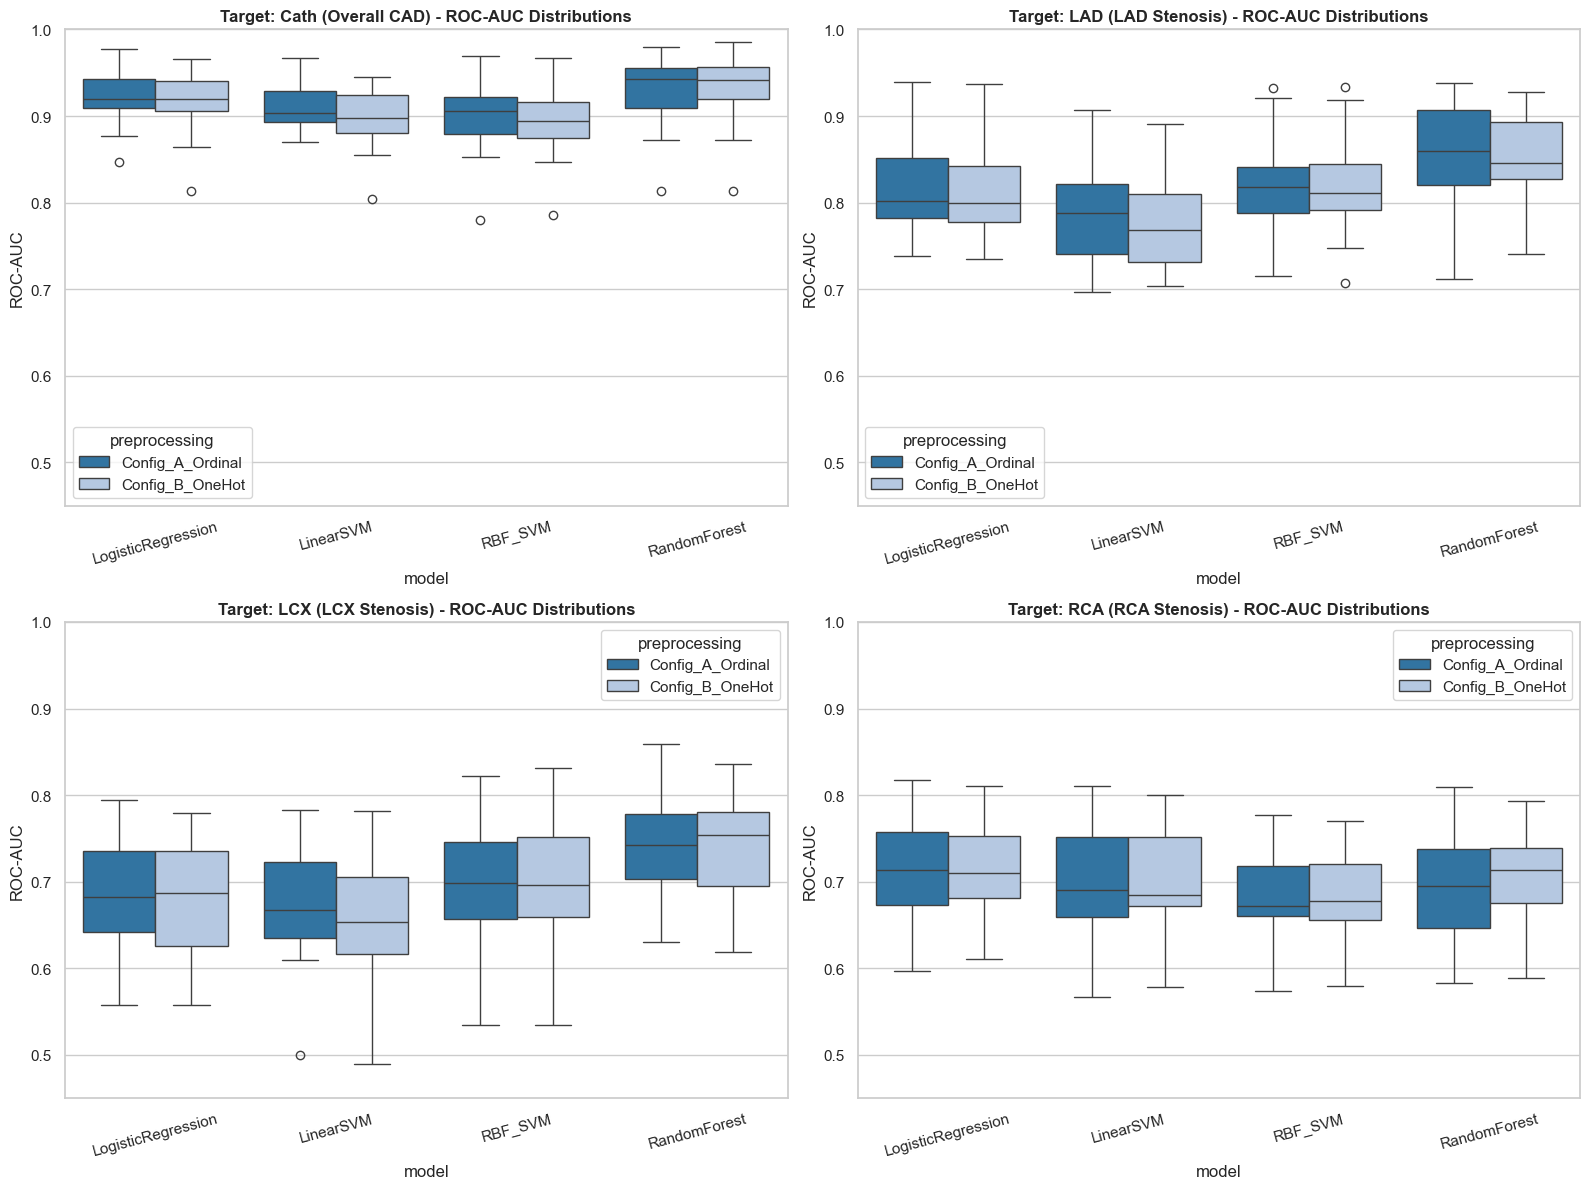

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, target in enumerate(TARGET_COLUMNS):
    target_data = baseline_results_df[baseline_results_df['target'] == target]
    sns.boxplot(
        data=target_data,
        x='model',
        y='roc_auc',
        hue='preprocessing',
        ax=axes[i],
        palette=['#1f77b4', '#aec7e8']
    )
    axes[i].set_title(f"Target: {target} ({TARGETS[target]['label']}) - ROC-AUC Distributions", fontweight='bold')
    axes[i].set_ylim(0.45, 1.0)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=15)
    axes[i].set_ylabel("ROC-AUC")

plt.tight_layout()
plt.show()

## 14. First-Repetition Out-of-Fold Confusion Matrices
Diagnostic confusion matrices constructed strictly from the first 5-fold repetition on the development set, providing a concrete view of false positives and false negatives on all 242 records. The main numerical performance summaries in Section 10 incorporate all 25 evaluations across all 5 repeats.

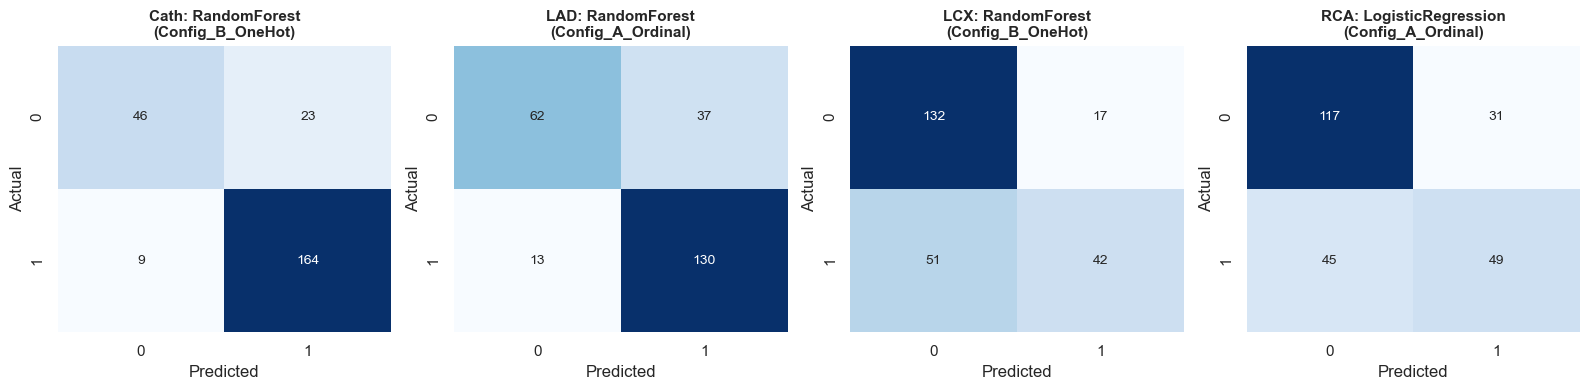

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, target in enumerate(TARGET_COLUMNS):
    best_m = summary_df[summary_df['target'] == target].sort_values('roc_auc_mean', ascending=False).iloc[0]
    oof_key = f"{target}__{best_m['preprocessing']}__{best_m['model']}"
    y_true = y_dev[target]
    y_pred = rep1_oof_dict[oof_key]['pred']

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"{target}: {best_m['model']}\n({best_m['preprocessing']})", fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 15. Target Difficulty & Error Analysis
Empirical ranking of target predictability across the four clinical tasks. For Overall CAD (Cath), Random Forest with Config B is the top-performing baseline (ROC-AUC = 0.932 +/- 0.039, F1 = 0.912 +/- 0.026).

In [15]:
difficulty_records = []
for target in TARGET_COLUMNS:
    t_summary = summary_df[summary_df['target'] == target]
    best_row = t_summary.sort_values('roc_auc_mean', ascending=False).iloc[0]
    difficulty_records.append({
        'Target': target,
        'Clinical Role': TARGETS[target]['label'],
        'Dev Prevalence %': round(TARGETS[target]['dev_pos_pct'], 1),
        'Best Baseline Model': best_row['model'],
        'Best Preprocessing': best_row['preprocessing'],
        'Top Mean ROC-AUC': round(best_row['roc_auc_mean'], 3),
        'Top Mean F1': round(best_row['f1_mean'], 3),
        'Top Mean Recall': round(best_row['recall_mean'], 3),
        'Top Mean Precision': round(best_row['precision_mean'], 3),
        'ROC-AUC Std Dev': round(best_row['roc_auc_std'], 3)
    })

difficulty_df = pd.DataFrame(difficulty_records).sort_values('Top Mean ROC-AUC', ascending=False)
display(difficulty_df)

,Target,Clinical Role,Dev Prevalence %,Best Baseline Model,Best Preprocessing,Top Mean ROC-AUC,Top Mean F1,Top Mean Recall,Top Mean Precision,ROC-AUC Std Dev
0,Cath,Overall CAD,71.5,RandomForest,Config_B_OneHot,0.932,0.912,0.947,0.881,0.039
1,LAD,LAD Stenosis,59.1,RandomForest,Config_A_Ordinal,0.854,0.845,0.899,0.798,0.056
2,LCX,LCX Stenosis,38.4,RandomForest,Config_B_OneHot,0.745,0.501,0.412,0.686,0.055
3,RCA,RCA Stenosis,38.8,LogisticRegression,Config_A_Ordinal,0.719,0.546,0.518,0.590,0.057


## 16. Target-Specific Benchmark Shortlist for Notebook 4
Construct a targeted shortlist identifying the best configuration for ROC-AUC, F1, and Recall for each target. These shortlisted baselines serve as direct benchmark references against gradient boosting models in Notebook 4.

In [16]:
benchmark_shortlist = []

for target in TARGET_COLUMNS:
    t_sum = summary_df[summary_df['target'] == target]
    
    # 1. Best ROC-AUC configuration
    best_auc_row = t_sum.sort_values('roc_auc_mean', ascending=False).iloc[0]
    benchmark_shortlist.append({
        'Target': target,
        'Benchmark Criterion': 'Best ROC-AUC',
        'Model': best_auc_row['model'],
        'Preprocessing': best_auc_row['preprocessing'],
        'ROC-AUC': f"{best_auc_row['roc_auc_mean']:.3f} +/- {best_auc_row['roc_auc_std']:.3f}",
        'F1': f"{best_auc_row['f1_mean']:.3f} +/- {best_auc_row['f1_std']:.3f}",
        'Recall': f"{best_auc_row['recall_mean']:.3f} +/- {best_auc_row['recall_std']:.3f}"
    })
    
    # 2. Best F1 configuration
    best_f1_row = t_sum.sort_values('f1_mean', ascending=False).iloc[0]
    if (best_f1_row['model'], best_f1_row['preprocessing']) != (best_auc_row['model'], best_auc_row['preprocessing']):
        benchmark_shortlist.append({
            'Target': target,
            'Benchmark Criterion': 'Best F1',
            'Model': best_f1_row['model'],
            'Preprocessing': best_f1_row['preprocessing'],
            'ROC-AUC': f"{best_f1_row['roc_auc_mean']:.3f} +/- {best_f1_row['roc_auc_std']:.3f}",
            'F1': f"{best_f1_row['f1_mean']:.3f} +/- {best_f1_row['f1_std']:.3f}",
            'Recall': f"{best_f1_row['recall_mean']:.3f} +/- {best_f1_row['recall_std']:.3f}"
        })
        
    # 3. Best Recall configuration
    best_rec_row = t_sum.sort_values('recall_mean', ascending=False).iloc[0]
    if (best_rec_row['model'], best_rec_row['preprocessing']) not in [
        (best_auc_row['model'], best_auc_row['preprocessing']),
        (best_f1_row['model'], best_f1_row['preprocessing'])
    ]:
        benchmark_shortlist.append({
            'Target': target,
            'Benchmark Criterion': 'Best Recall',
            'Model': best_rec_row['model'],
            'Preprocessing': best_rec_row['preprocessing'],
            'ROC-AUC': f"{best_rec_row['roc_auc_mean']:.3f} +/- {best_rec_row['roc_auc_std']:.3f}",
            'F1': f"{best_rec_row['f1_mean']:.3f} +/- {best_rec_row['f1_std']:.3f}",
            'Recall': f"{best_rec_row['recall_mean']:.3f} +/- {best_rec_row['recall_std']:.3f}"
        })

benchmark_df = pd.DataFrame(benchmark_shortlist)
print("Target-Specific Baseline Benchmark Shortlist for Notebook 4:")
display(benchmark_df)

Target-Specific Baseline Benchmark Shortlist for Notebook 4:


,Target,Benchmark Criterion,Model,Preprocessing,ROC-AUC,F1,Recall
0,Cath,Best ROC-AUC,RandomForest,Config_B_OneHot,0.932 +/- 0.039,0.912 +/- 0.026,0.947 +/- 0.039
1,LAD,Best ROC-AUC,RandomForest,Config_A_Ordinal,0.854 +/- 0.056,0.845 +/- 0.046,0.899 +/- 0.047
2,LCX,Best ROC-AUC,RandomForest,Config_B_OneHot,0.745 +/- 0.055,0.501 +/- 0.098,0.412 +/- 0.123
3,LCX,Best F1,RandomForest,Config_A_Ordinal,0.742 +/- 0.061,0.516 +/- 0.069,0.431 +/- 0.094
4,LCX,Best Recall,LogisticRegression,Config_B_OneHot,0.678 +/- 0.064,0.503 +/- 0.081,0.474 +/- 0.114
5,RCA,Best ROC-AUC,LogisticRegression,Config_A_Ordinal,0.719 +/- 0.057,0.546 +/- 0.087,0.518 +/- 0.110


## 17. Save Experiment Artifacts
Persist long-form fold metrics and summary tables into artifacts directory.

In [17]:
Path('artifacts').mkdir(exist_ok=True)

baseline_results_df.to_csv('artifacts/notebook3_baseline_fold_results.csv', index=False)
summary_df.to_csv('artifacts/notebook3_baseline_summary.csv', index=False)
comparison_df.to_csv('artifacts/notebook3_preprocessing_comparison.csv')
benchmark_df.to_csv('artifacts/notebook3_benchmark_shortlist.csv', index=False)

metadata = {
    'notebook': '03_Baseline_Models.ipynb',
    'total_evaluations': len(baseline_results_df),
    'development_cohort_size': len(X_dev),
    'holdout_cohort_size': len(X_holdout),
    'targets_evaluated': TARGET_COLUMNS,
    'models_evaluated': list(BASE_MODELS.keys()),
    'preprocessing_configurations': list(PREPROCESSORS.keys()),
    'holdout_status': 'SEALED_UNTOUCHED'
}

with open('artifacts/notebook3_experiment_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("Saved all experiment artifacts to artifacts/ directory.")

Saved all experiment artifacts to artifacts/ directory.


## 18. Findings & Handoff to Notebook 4
Synthesized baseline takeaways governing boosting model design in Notebook 4.

In [18]:
handoff_takeaways = pd.DataFrame([
    {'Dimension': 'Overall CAD (Cath)', 'Finding': 'Random Forest + Config B is top baseline (ROC-AUC = 0.932 +/- 0.039, F1 = 0.912 +/- 0.026)', 'Implication for Notebook 4': 'Sets high reference performance; evaluate if gradient boosting exceeds RF on non-linear feature interactions.'},
    {'Dimension': 'Vessel Stenosis (LAD/LCX/RCA)', 'Finding': 'LAD best is RF Config A (0.854 +/- 0.056); LCX best is RF Config B (0.745 +/- 0.055); RCA best is Logistic Config A (0.719 +/- 0.057)', 'Implication for Notebook 4': 'Boosting algorithms (XGBoost/LightGBM) will test gradient boosting across ECG & echo features.'},
    {'Dimension': 'Preprocessing (VHD A vs B)', 'Finding': 'Largest observed absolute mean ROC-AUC difference is ~0.020 (LCX LinearSVM)', 'Implication for Notebook 4': 'Preprocessing effects are model- and target-dependent; retain both configurations in Notebook 4.'},
    {'Dimension': 'Holdout Set Status', 'Finding': 'Untouched (N=61)', 'Implication for Notebook 4': 'Holdout remains strictly sealed until Notebook 6.'}
])
display(handoff_takeaways)
print("Notebook 3 complete. Handoff contract ready for Notebook 4 (Gradient Boosting: XGBoost & LightGBM).")

,Dimension,Finding,Implication for Notebook 4
0,Overall CAD (Cath),Random Forest + Config B is top baseline (ROC-...,Sets high reference performance; evaluate if g...
1,Vessel Stenosis (LAD/LCX/RCA),LAD best is RF Config A (0.854 +/- 0.056); LCX...,Boosting algorithms (XGBoost/LightGBM) will te...
2,Preprocessing (VHD A vs B),Largest observed absolute mean ROC-AUC differe...,Preprocessing effects are model- and target-de...
3,Holdout Set Status,Untouched (N=61),Holdout remains strictly sealed until Notebook 6.


Notebook 3 complete. Handoff contract ready for Notebook 4 (Gradient Boosting: XGBoost & LightGBM).
